<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/4_Custom_Gradient_Descent_Optimizers_with_Momentum%2C_RMSprop%2C_and_Adam_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

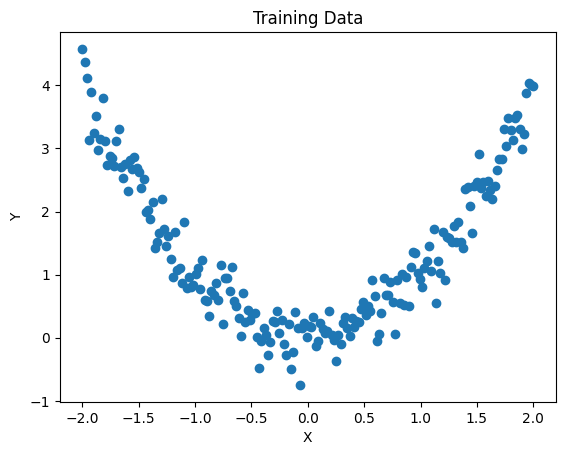

In [2]:
# Generate Non-linear Dataset

X = torch.linspace(-2, 2, 200).reshape(-1,1)

Y = X**2 + 0.3*torch.randn_like(X)

plt.scatter(X.numpy(), Y.numpy())
plt.title("Training Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [3]:
# Model Parameters

W = torch.randn(1,1)

b = torch.randn(1)

learning_rate = 0.01

epochs = 300

In [4]:
def forward(x):

    return x @ W + b

In [5]:
def loss_fn(pred,target):

    return torch.mean((pred-target)**2)

In [6]:
velocity_W = torch.zeros_like(W)
velocity_b = torch.zeros_like(b)

beta = 0.9

In [7]:
cache_W = torch.zeros_like(W)
cache_b = torch.zeros_like(b)

beta_rms = 0.99
eps = 1e-8

In [8]:
mW = torch.zeros_like(W)
vW = torch.zeros_like(W)

mb = torch.zeros_like(b)
vb = torch.zeros_like(b)

beta1 = 0.9
beta2 = 0.999

In [9]:
loss_history = []

for epoch in range(1, epochs+1):

    # Forward
    pred = forward(X)

    loss = loss_fn(pred,Y)

    loss_history.append(loss.item())

    # Manual Gradients

    grad_output = 2*(pred-Y)/len(X)

    grad_W = X.t() @ grad_output

    grad_b = grad_output.sum()

    # ===========================
    # Choose ONE Optimizer
    # ===========================

    optimizer = "adam"

    if optimizer=="momentum":

        velocity_W = beta*velocity_W + learning_rate*grad_W
        velocity_b = beta*velocity_b + learning_rate*grad_b

        W -= velocity_W
        b -= velocity_b

    elif optimizer=="rmsprop":

        cache_W = beta_rms*cache_W + (1-beta_rms)*(grad_W**2)
        cache_b = beta_rms*cache_b + (1-beta_rms)*(grad_b**2)

        W -= learning_rate*grad_W/(torch.sqrt(cache_W)+eps)
        b -= learning_rate*grad_b/(torch.sqrt(cache_b)+eps)

    elif optimizer=="adam":

        mW = beta1*mW + (1-beta1)*grad_W
        vW = beta2*vW + (1-beta2)*(grad_W**2)

        mb = beta1*mb + (1-beta1)*grad_b
        vb = beta2*vb + (1-beta2)*(grad_b**2)

        mW_hat = mW/(1-beta1**epoch)
        vW_hat = vW/(1-beta2**epoch)

        mb_hat = mb/(1-beta1**epoch)
        vb_hat = vb/(1-beta2**epoch)

        W -= learning_rate*mW_hat/(torch.sqrt(vW_hat)+eps)
        b -= learning_rate*mb_hat/(torch.sqrt(vb_hat)+eps)

    if epoch%50==0:

        print(f"Epoch {epoch} Loss = {loss.item():.4f}")

Epoch 50 Loss = 4.8562
Epoch 100 Loss = 3.0911
Epoch 150 Loss = 2.2040
Epoch 200 Loss = 1.7895
Epoch 250 Loss = 1.6062
Epoch 300 Loss = 1.5307


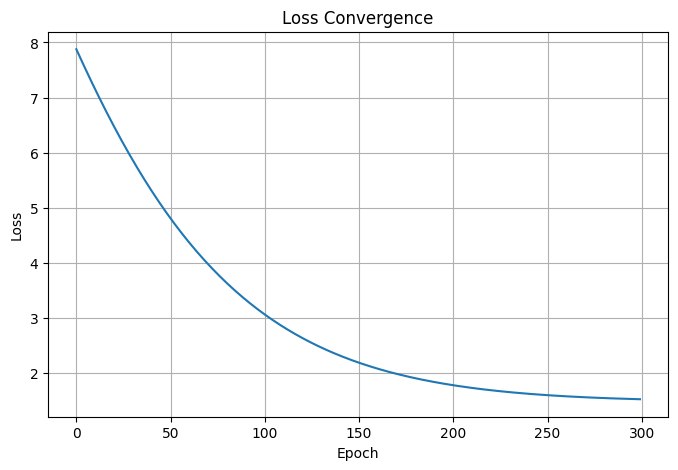

In [10]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("Loss Convergence")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

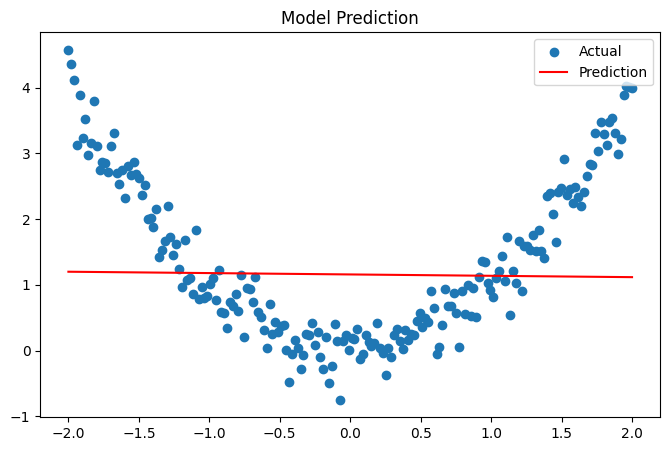

In [11]:
pred = forward(X)

plt.figure(figsize=(8,5))

plt.scatter(X.numpy(),Y.numpy(),label="Actual")

plt.plot(X.numpy(),pred.detach().numpy(),color='red',label="Prediction")

plt.legend()

plt.title("Model Prediction")

plt.show()